# Predicting Electric Vehicle Purchases — Playground Series S6E9

Kaggle: https://www.kaggle.com/competitions/playground-series-s6e9

Binary classification: predict `Will_Buy_EV` from demographic, commute, and infrastructure
features. Metric: **ROC AUC**.

Pipeline, in order:
1. Data understanding (EDA)
2. Feature engineering
3. Modeling with in-training monitoring (learning curves, CV stability), folds parallelized
   as separate processes (see [`01-predicting-airline-satisfaction`](../01-predicting-airline-satisfaction/)
   for the benchmark behind that choice)
4. Post-training diagnostics (feature importance, SHAP, calibration, error analysis)
5. Final CV metric and held-out leaderboard score
6. Full-data fit + submission


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, brier_score_loss
from sklearn.calibration import calibration_curve
import lightgbm as lgb

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


## 1. Data understanding

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
train.head()


train: (668665, 15)  test: (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [4]:
missing = pd.concat([train.isna().sum(), test.isna().sum()], axis=1, keys=["train_na", "test_na"])
missing[(missing["train_na"] > 0) | (missing["test_na"] > 0)]


,train_na,test_na


No missing values in either split.

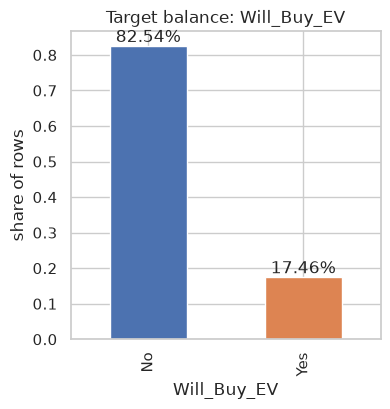

Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
train["Will_Buy_EV"].value_counts(normalize=True).plot(
    kind="bar", ax=ax, color=["#4C72B0", "#DD8452"]
)
ax.set_title("Target balance: Will_Buy_EV")
ax.set_ylabel("share of rows")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()
print(train["Will_Buy_EV"].value_counts(normalize=True))


Target is imbalanced (~82.5% No / 17.5% Yes). ROC AUC is still a sound choice here since it's threshold-free and insensitive to the imbalance itself — but it means a trivial always-predict-No baseline would score ~0.5 AUC while still being 82.5% "accurate", so accuracy would have been a misleading metric for this problem.

In [6]:
num_cols = ["Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
            "Charging_Stations_Near_Home", "Charging_Stations_Near_Work", "Environmental_Concern_Level"]
cat_cols = ["Gender", "City_Type", "Current_Car_Type", "Home_Charging_Possible",
            "Subsidy_Available", "Range_Anxiety_Level"]
print("numeric:", num_cols)
print("categorical:", cat_cols)


numeric: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
categorical: ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


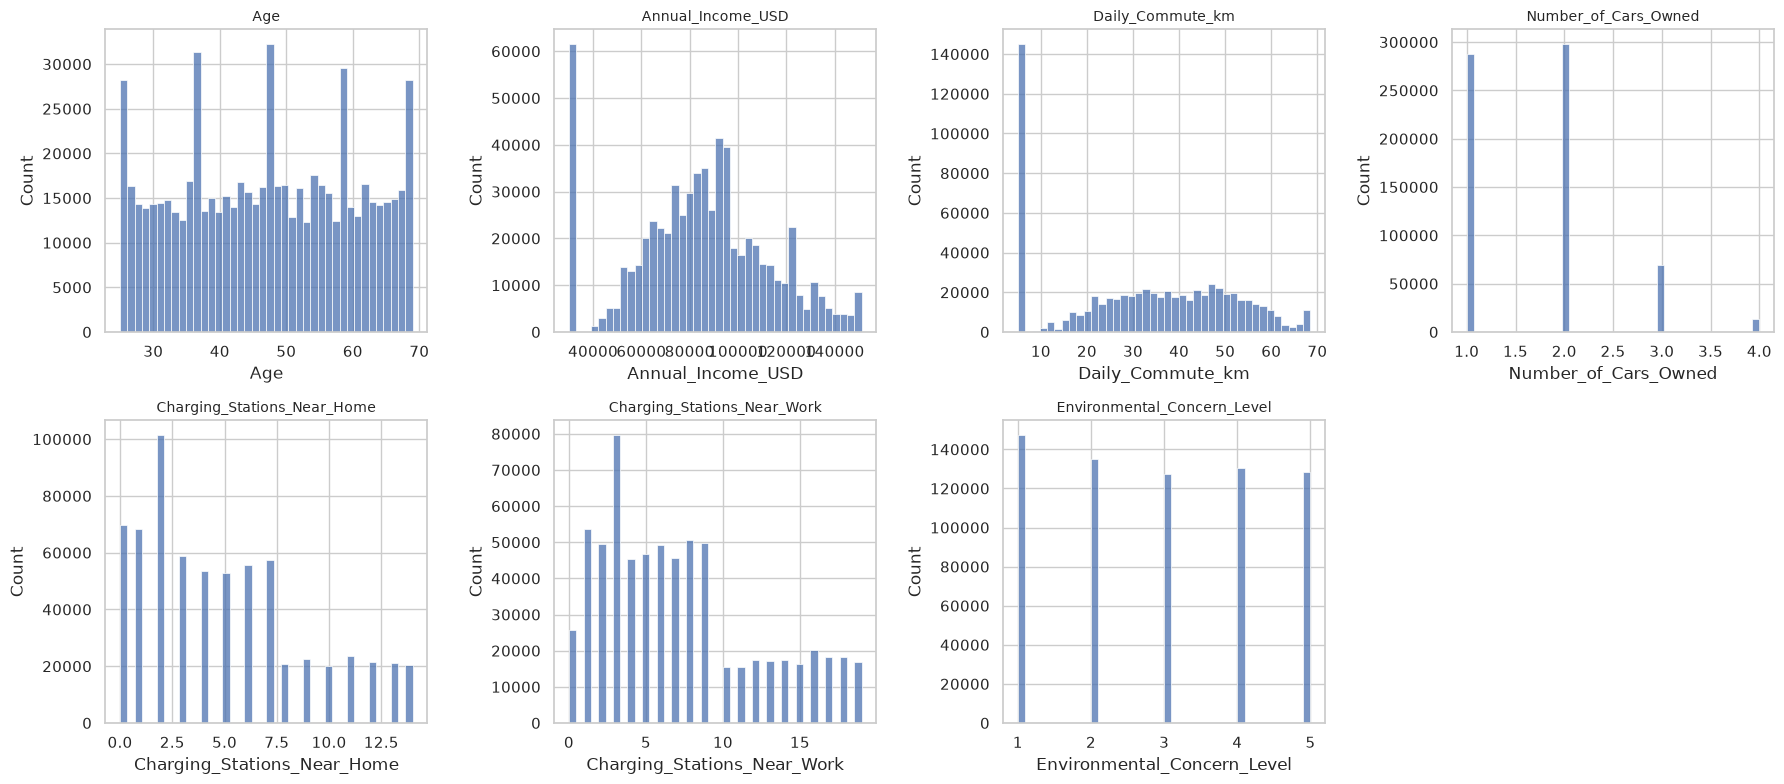

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(train[c].clip(upper=train[c].quantile(0.99)), ax=ax, bins=40, color="#4C72B0")
    ax.set_title(c, fontsize=10)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()


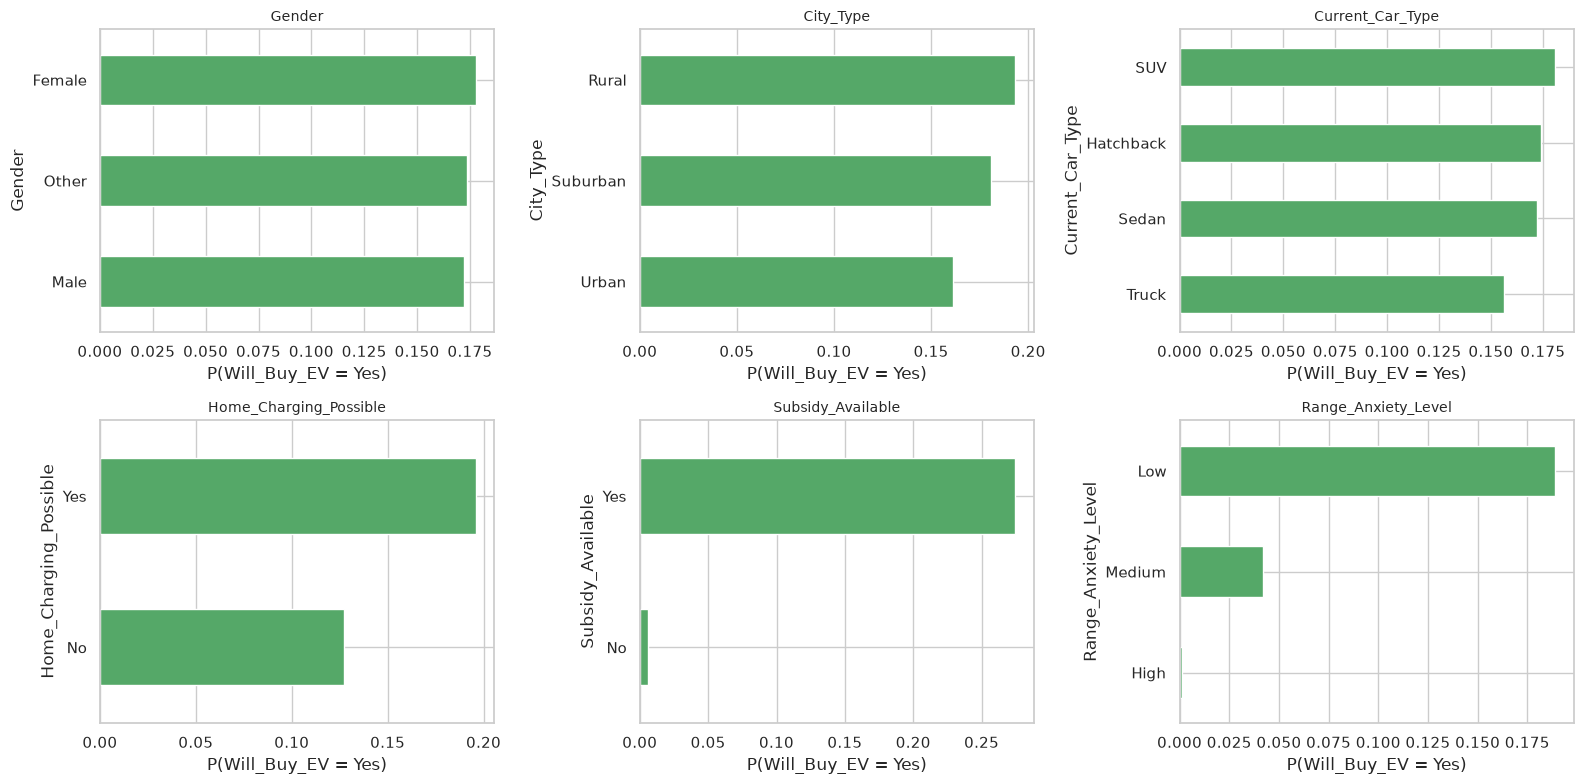

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), cat_cols):
    rate = train.groupby(c)["Will_Buy_EV"].apply(lambda s: (s == "Yes").mean()).sort_values()
    rate.plot(kind="barh", ax=ax, color="#55A868")
    ax.set_title(c, fontsize=10)
    ax.set_xlabel("P(Will_Buy_EV = Yes)")
plt.tight_layout()
plt.show()


`Subsidy_Available`, `Home_Charging_Possible`, and `Range_Anxiety_Level` show the widest spread in purchase rate — these look like the strongest categorical signals, which lines up with intuition: subsidies and home charging remove the two biggest practical barriers to EV ownership, and range anxiety directly measures willingness.

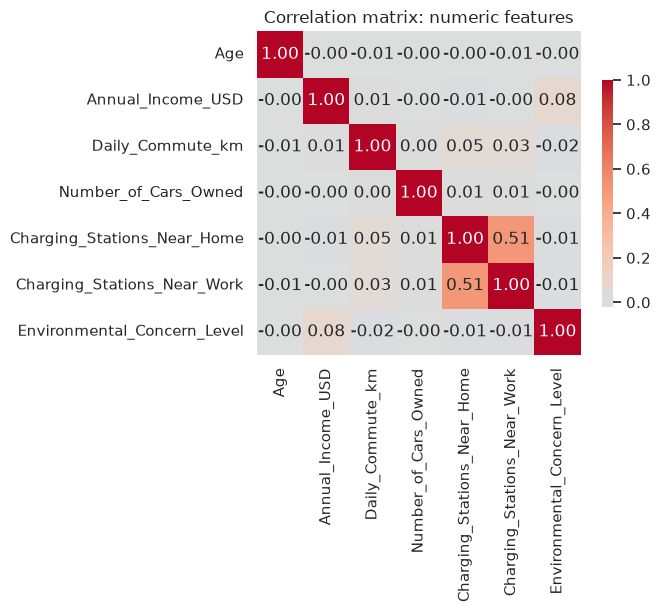

In [9]:
corr = train[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True, annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.7})
ax.set_title("Correlation matrix: numeric features")
plt.tight_layout()
plt.show()


Numeric features are close to independent of each other — no redundant pairs to drop or combine before modeling.

## 2. Feature engineering

In [10]:
def build_features(df):
    out = df.drop(columns=["id"]).copy()
    for c in cat_cols:
        out[c] = out[c].astype("category")
    out["income_per_commute_km"] = out["Annual_Income_USD"] / (out["Daily_Commute_km"] + 1)
    out["total_charging_nearby"] = out["Charging_Stations_Near_Home"] + out["Charging_Stations_Near_Work"]
    out["cars_per_commute_km"] = out["Number_of_Cars_Owned"] / (out["Daily_Commute_km"] + 1)
    return out

y = (train["Will_Buy_EV"] == "Yes").astype(int)
X = build_features(train.drop(columns=["Will_Buy_EV"]))
X_test = build_features(test)
feature_cols = X.columns.tolist()
print(X.shape, X_test.shape)
X.head()


(668665, 16) (286571, 16)


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,income_per_commute_km,total_charging_nearby,cars_per_commute_km
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,3806.844262,10,0.081967
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,5000.000000,4,0.166667
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,2497.063492,23,0.026455
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,2978.947368,15,0.080972
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,1117.722008,5,0.019305


Added: income relative to commute distance (afford-to-charge-at-destination proxy), total nearby charging stations (home + work combined), and cars owned relative to commute distance (how much a household's existing fleet absorbs daily driving).

## 3. Modeling — 5-fold CV with in-training monitoring, parallel folds

Same approach validated in competition #1: the 5 CV folds are independent units, trained as 5
separate OS processes (`joblib`, `loky` backend, LightGBM `num_threads=1` per process) rather than
leaning on LightGBM's own in-process threading.


In [11]:
N_FOLDS = 5
N_JOBS = min(N_FOLDS, os.cpu_count() or N_FOLDS)
print(f"cpu_count={os.cpu_count()}  parallel_folds={N_JOBS}")

params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    lambda_l2=1.0,
    verbosity=-1,
    seed=RANDOM_STATE,
    num_threads=1,
)

def train_fold(fold, tr_idx, va_idx, X, y, X_test, cat_cols, params):
    import lightgbm as lgb
    from sklearn.metrics import roc_auc_score

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols, free_raw_data=False)
    dvalid = lgb.Dataset(X_va, label=y_va, categorical_feature=cat_cols, reference=dtrain, free_raw_data=False)

    evals_result = {}
    model = lgb.train(
        params, dtrain,
        num_boost_round=2000,
        valid_sets=[dtrain, dvalid],
        valid_names=["train", "valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.record_evaluation(evals_result),
        ],
    )
    va_pred = model.predict(X_va, num_iteration=model.best_iteration)
    test_pred = model.predict(X_test, num_iteration=model.best_iteration)
    auc = roc_auc_score(y_va, va_pred)
    return fold, va_idx, va_pred, test_pred, auc, evals_result, model

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
splits = list(skf.split(X, y))

t0 = time.time()
results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=15)(
    delayed(train_fold)(fold, tr_idx, va_idx, X, y, X_test, cat_cols, params)
    for fold, (tr_idx, va_idx) in enumerate(splits)
)
results.sort(key=lambda r: r[0])
print(f"5-fold parallel training wall time: {time.time() - t0:.1f}s")

oof_pred = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_aucs = []
fold_models = []
first_fold_evals = None

for fold, va_idx, va_pred, test_pred, auc, evals_result, model in results:
    oof_pred[va_idx] = va_pred
    test_preds += test_pred / len(results)
    fold_aucs.append(auc)
    fold_models.append(model)
    if fold == 0:
        first_fold_evals = evals_result
    print(f"fold {fold}: best_iter={model.best_iteration:4d}  valid AUC={auc:.5f}")

print(f"\nCV AUC: {np.mean(fold_aucs):.5f} +/- {np.std(fold_aucs):.5f}")


cpu_count=32  parallel_folds=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed:   57.4s


[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  1.0min remaining:  1.5min


[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  1.1min remaining:   43.1s


5-fold parallel training wall time: 72.8s
fold 0: best_iter= 369  valid AUC=0.94037
fold 1: best_iter= 319  valid AUC=0.94130
fold 2: best_iter= 299  valid AUC=0.94273
fold 3: best_iter= 426  valid AUC=0.94218
fold 4: best_iter= 366  valid AUC=0.94163

CV AUC: 0.94164 +/- 0.00080


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  1.2min finished


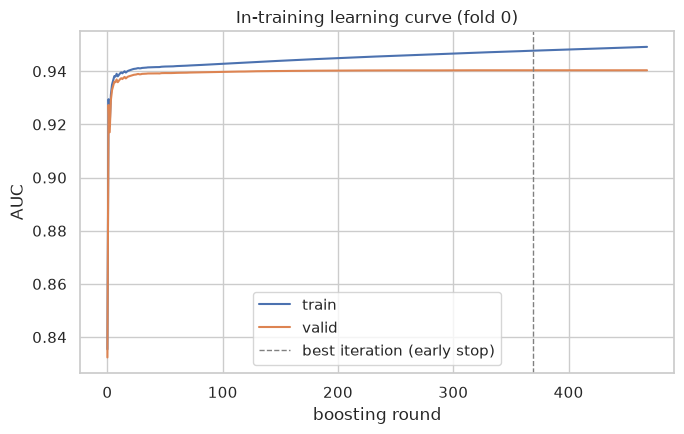

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(first_fold_evals["train"]["auc"], label="train")
ax.plot(first_fold_evals["valid"]["auc"], label="valid")
ax.axvline(fold_models[0].best_iteration, color="gray", ls="--", lw=1, label="best iteration (early stop)")
ax.set_xlabel("boosting round")
ax.set_ylabel("AUC")
ax.set_title("In-training learning curve (fold 0)")
ax.legend()
plt.tight_layout()
plt.show()


Train and validation AUC track closely with a small, stable gap, and early stopping lands well short of the round cap — no overfitting runaway.

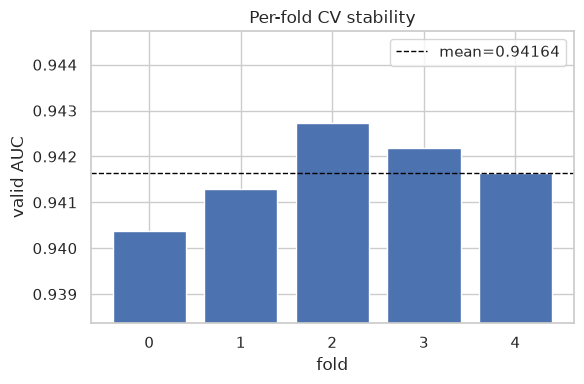

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(fold_aucs)), fold_aucs, color="#4C72B0")
ax.axhline(np.mean(fold_aucs), color="black", ls="--", lw=1, label=f"mean={np.mean(fold_aucs):.5f}")
ax.set_xlabel("fold")
ax.set_ylabel("valid AUC")
ax.set_title("Per-fold CV stability")
ax.set_ylim(min(fold_aucs) - 0.002, max(fold_aucs) + 0.002)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Post-training diagnostics

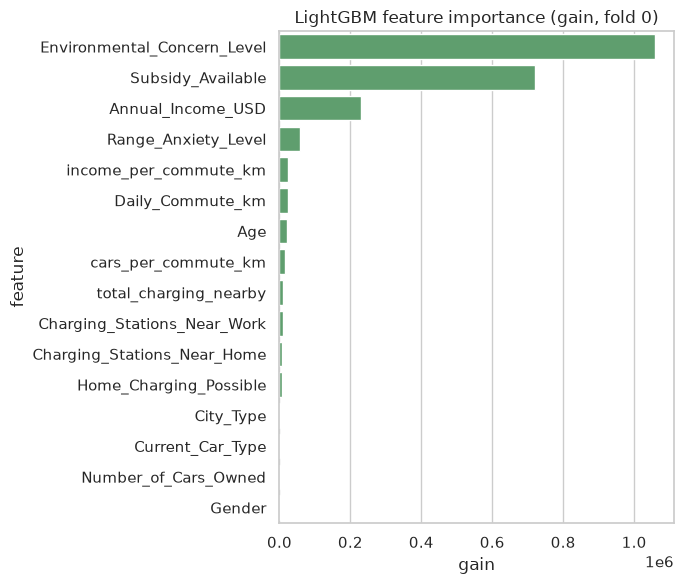

,feature,gain
6,Environmental_Concern_Level,1.059424e+06
11,Subsidy_Available,7.211605e+05
1,Annual_Income_USD,2.292524e+05
12,Range_Anxiety_Level,5.661896e+04
13,income_per_commute_km,2.531545e+04
2,Daily_Commute_km,2.427428e+04
0,Age,1.982837e+04
15,cars_per_commute_km,1.494942e+04
14,total_charging_nearby,9.942544e+03
5,Charging_Stations_Near_Work,8.517104e+03


In [14]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "gain": fold_models[0].feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(data=imp, y="feature", x="gain", ax=ax, color="#55A868")
ax.set_title("LightGBM feature importance (gain, fold 0)")
plt.tight_layout()
plt.show()
imp


/usr/local/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


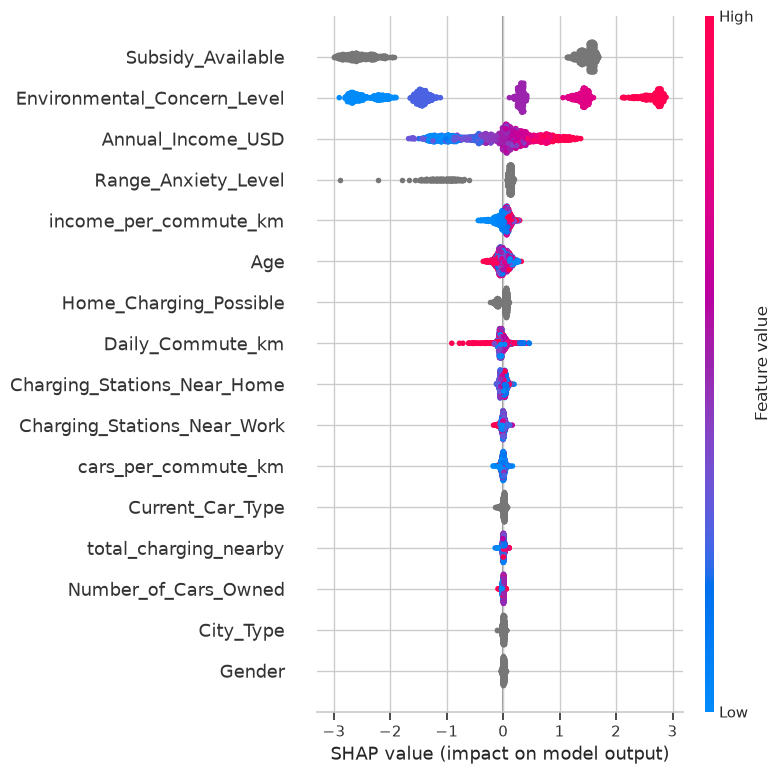

In [15]:
import shap
explainer = shap.TreeExplainer(fold_models[0])
sample = X.sample(2000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.show()


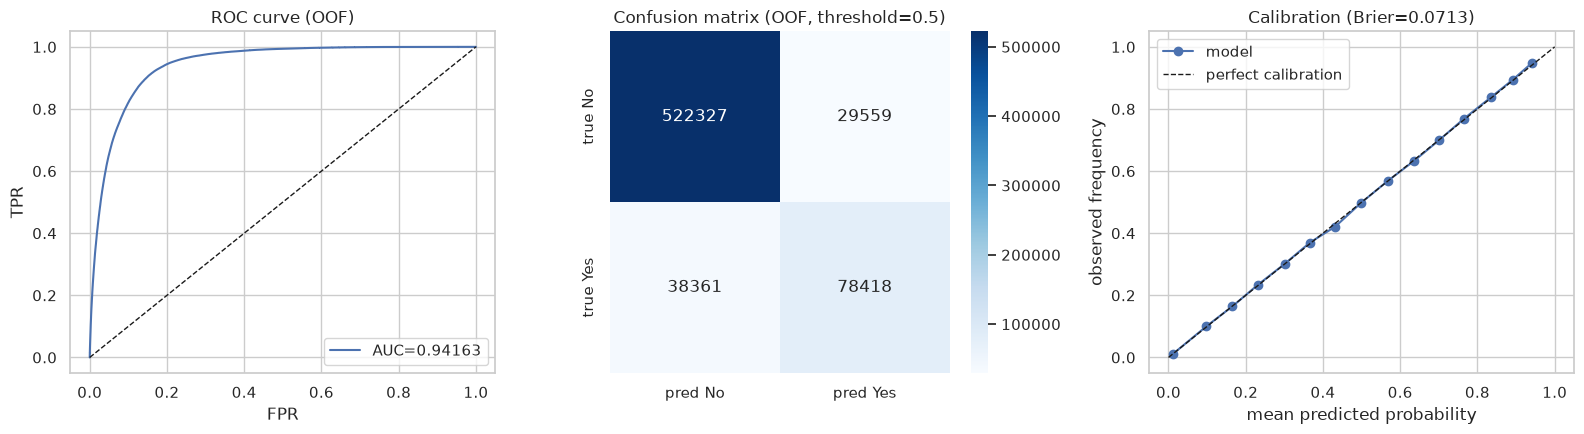

In [16]:
fpr, tpr, _ = roc_curve(y, oof_pred)
auc = roc_auc_score(y, oof_pred)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(fpr, tpr, label=f"AUC={auc:.5f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC curve (OOF)")
axes[0].legend()

cm = confusion_matrix(y, (oof_pred >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["pred No", "pred Yes"], yticklabels=["true No", "true Yes"])
axes[1].set_title("Confusion matrix (OOF, threshold=0.5)")

prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=15)
axes[2].plot(prob_pred, prob_true, marker="o", label="model")
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[2].set_xlabel("mean predicted probability"); axes[2].set_ylabel("observed frequency")
axes[2].set_title(f"Calibration (Brier={brier_score_loss(y, oof_pred):.4f})")
axes[2].legend()

plt.tight_layout()
plt.show()


At the default 0.5 threshold the confusion matrix will under-predict the minority "Yes" class, as expected from an 82.5/17.5 imbalance with no resampling — that's a threshold choice, not a ranking problem, which is exactly why ROC AUC (threshold-free) is the metric this competition actually scores on rather than accuracy at a fixed cutoff.

In [17]:
errors = X.copy()
errors["y_true"] = y.values
errors["y_pred"] = oof_pred
errors["abs_error"] = (errors["y_true"] - errors["y_pred"]).abs()

print("Mean |error| by City_Type:")
print(errors.groupby("City_Type")["abs_error"].mean().sort_values(ascending=False))
print("\nMean |error| by Range_Anxiety_Level:")
print(errors.groupby("Range_Anxiety_Level")["abs_error"].mean().sort_values(ascending=False))

worst = errors.sort_values("abs_error", ascending=False).head(10)
worst[["Age", "City_Type", "Range_Anxiety_Level", "Subsidy_Available", "y_true", "y_pred", "abs_error"]]


Mean |error| by City_Type:
City_Type
Rural       0.155304
Suburban    0.146630
Urban       0.133756
Name: abs_error, dtype: float64

Mean |error| by Range_Anxiety_Level:
Range_Anxiety_Level
Low       0.151538
Medium    0.061601
High      0.010365
Name: abs_error, dtype: float64


,Age,City_Type,Range_Anxiety_Level,Subsidy_Available,y_true,y_pred,abs_error
656804,39,Suburban,Medium,No,1,0.000249,0.999751
513302,65,Suburban,Low,No,1,0.000254,0.999746
521834,31,Urban,Low,No,1,0.000277,0.999723
528318,30,Rural,Low,No,1,0.000295,0.999705
378738,32,Rural,Low,No,1,0.000405,0.999595
105128,49,Suburban,Low,No,1,0.000432,0.999568
316169,46,Urban,Low,No,1,0.000437,0.999563
193484,27,Urban,Low,No,1,0.000493,0.999507
532292,25,Suburban,Low,No,1,0.000517,0.999483
494417,45,Urban,Low,No,1,0.000523,0.999477


## 5. Final metric

**5-fold CV ROC AUC — the metric this competition is scored on.**


In [18]:
print(f"Final CV ROC AUC (OOF): {roc_auc_score(y, oof_pred):.5f}")
print(f"Per-fold: {[round(a, 5) for a in fold_aucs]}")


Final CV ROC AUC (OOF): 0.94163
Per-fold: [0.94037, 0.9413, 0.94273, 0.94218, 0.94163]


## 6. Submission

In [19]:
submission = pd.DataFrame({"id": test["id"], "Will_Buy_EV": test_preds})
submission.to_csv("submission.csv", index=False)
submission.head()


,id,Will_Buy_EV
0,668665,0.008806
1,668666,0.021736
2,668667,0.006373
3,668668,0.003164
4,668669,0.017485
